In [1]:
import keras
import tensorflow as tf
from keras import layers as tfkl
import numpy as np
import matplotlib.pyplot as plt
import os

print(tf.__version__)
print(keras.__version__)


2.10.0
2.10.0


# Loading a pre-trained model and MNIST dataset

In [4]:
# Constants
MODEL_PATH = 'gan_gen_dim20.keras'
M = 300
N = 784
k = 32
index = 4
eta = 0.01
num_epochs = 300
tries = 1
latent_dim = 20

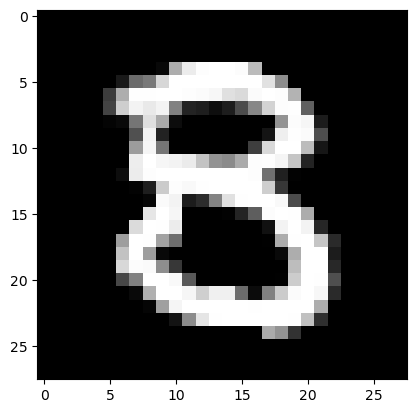

In [5]:
# Load NN model
G = keras.models.load_model(MODEL_PATH)
# Load chose dataset (MNIST)
(training_x,training_y) , (test_x , test_y) = tf.keras.datasets.mnist.load_data()
# Generate an image giving a random vectori in input to the NN to check the generatio capability
z = np.random.randn(1,latent_dim)
image = G(z)
plt.imshow(image[0,:,:,0],cmap='gray')

# Building a custom model using the pre-trained NN to minimize the error

In [6]:
# Ensure model layers are not trainable
G.trainable = True

for layer in G.layers:
    layer.trainable = False

# Generating the measurement matrix A
A = tf.constant(np.random.randn(M,N)* 1/M , shape=(M,N), dtype = tf.float32)
print(f'The shape of A is: {A.shape}')
# Generating the original image x_original
x_original = tf.constant(training_x[index,:,:].reshape(-1) , shape = (1,N), dtype = tf.float32)
print(f'The shape of x is: {x_original.shape}')
# Generating y
y = x_original @ tf.transpose(A) + tf.random.normal((1,M)) * eta
print(f'The shape of y is: {y.shape}')


The shape of A is: (300, 784)
The shape of x is: (1, 784)
The shape of y is: (1, 300)


In [7]:
# Define the loss function
def loss(z):
    Gz = G(z)
    Gz = Gz[0,:,:,0]
    Gz = tf.reshape(Gz, [1, 784])
    diff = tf.matmul(Gz,A , transpose_b=True) - y
    return tf.norm(diff)

# Optimization step
def train_step(z, optimizer):
    with tf.GradientTape() as tape:
        current_loss = loss(z)
    gradients = tape.gradient(current_loss, [z])
    optimizer.apply_gradients(zip(gradients, [z]))
    return current_loss

# Training loop
def train(num_epochs , tries , nn_input):
    best_loss = np.inf
    best_result = None
    for i in range(tries):
        z = tf.Variable(np.random.randn(1,nn_input)*0.01, dtype = tf.float32)
        optimizer = tf.optimizers.Adam(learning_rate=0.01)
        for epoch in range(num_epochs):
            current_loss = train_step(z , optimizer)
            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Loss: {current_loss.numpy()}')

        print(f'Optimized z has loss : {loss(z).numpy()}')
        if current_loss.numpy() < best_loss:
            best_loss = current_loss.numpy()
            best_result = z
    return best_loss , best_result

best_loss , z = train(400 , 5 , latent_dim)


Epoch 0, Loss: 123.65084838867188
Epoch 100, Loss: 123.40801239013672
Epoch 200, Loss: 123.39137268066406
Epoch 300, Loss: 123.38289642333984
Optimized z has loss : 123.37904357910156
Epoch 0, Loss: 123.64926147460938
Epoch 100, Loss: 123.41356658935547
Epoch 200, Loss: 123.38880920410156
Epoch 300, Loss: 123.38321685791016
Optimized z has loss : 123.3797607421875
Epoch 0, Loss: 123.64997100830078
Epoch 100, Loss: 123.41331481933594
Epoch 200, Loss: 123.38985443115234
Epoch 300, Loss: 123.38329315185547
Optimized z has loss : 123.3797607421875
Epoch 0, Loss: 123.64897918701172
Epoch 100, Loss: 123.4157943725586
Epoch 200, Loss: 123.39541625976562
Epoch 300, Loss: 123.3834457397461
Optimized z has loss : 123.37967681884766
Epoch 0, Loss: 123.64877319335938
Epoch 100, Loss: 123.41362762451172
Epoch 200, Loss: 123.38984680175781
Epoch 300, Loss: 123.38330078125
Optimized z has loss : 123.3797607421875


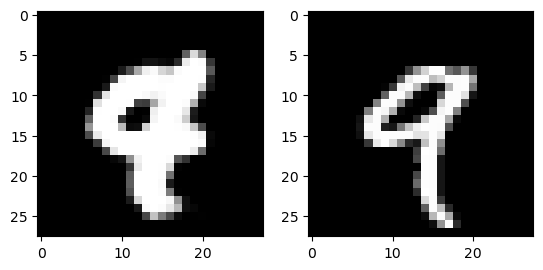

In [8]:
fig,axis = plt.subplots(1,2)
axis[0].imshow(G(z)[0,:,:,0], cmap='gray')
axis[1].imshow(training_x[index,:,:], cmap='gray')

# Reconstructing the image at various compression rates and checking the reconstruction error per pixel

In [9]:
losses = []
reconstructions = []
for M in range(20 , 784 , 50):
    A = tf.constant(np.random.randn(M,N)* 1/M , shape=(M,N), dtype = tf.float32)
    y = x_original @ tf.transpose(A) + tf.random.normal((1,M)) * eta
    best_loss , z = train(num_epochs , tries , latent_dim)
    print(f'For M = {M} , the best loss is {best_loss}')
    losses.append(best_loss)
    reconstructions.append(G(z)[0,:,:,0])

Epoch 0, Loss: 598.683349609375
Epoch 100, Loss: 597.765869140625
Epoch 200, Loss: 597.3048706054688
Optimized z has loss : 597.2516479492188
For M = 20 , the best loss is 597.2523193359375
Epoch 0, Loss: 211.25057983398438
Epoch 100, Loss: 210.8255615234375
Epoch 200, Loss: 210.49859619140625
Optimized z has loss : 210.4598388671875
For M = 70 , the best loss is 210.4601287841797
Epoch 0, Loss: 205.5551300048828
Epoch 100, Loss: 205.18649291992188
Epoch 200, Loss: 205.11795043945312
Optimized z has loss : 205.1153564453125
For M = 120 , the best loss is 205.1153564453125
Epoch 0, Loss: 175.9725341796875
Epoch 100, Loss: 175.6769256591797
Epoch 200, Loss: 175.65176391601562
Optimized z has loss : 175.64224243164062
For M = 170 , the best loss is 175.64256286621094
Epoch 0, Loss: 144.0500946044922
Epoch 100, Loss: 143.860595703125
Epoch 200, Loss: 143.8513641357422
Optimized z has loss : 143.84400939941406
For M = 220 , the best loss is 143.8440704345703
Epoch 0, Loss: 141.6933288574218

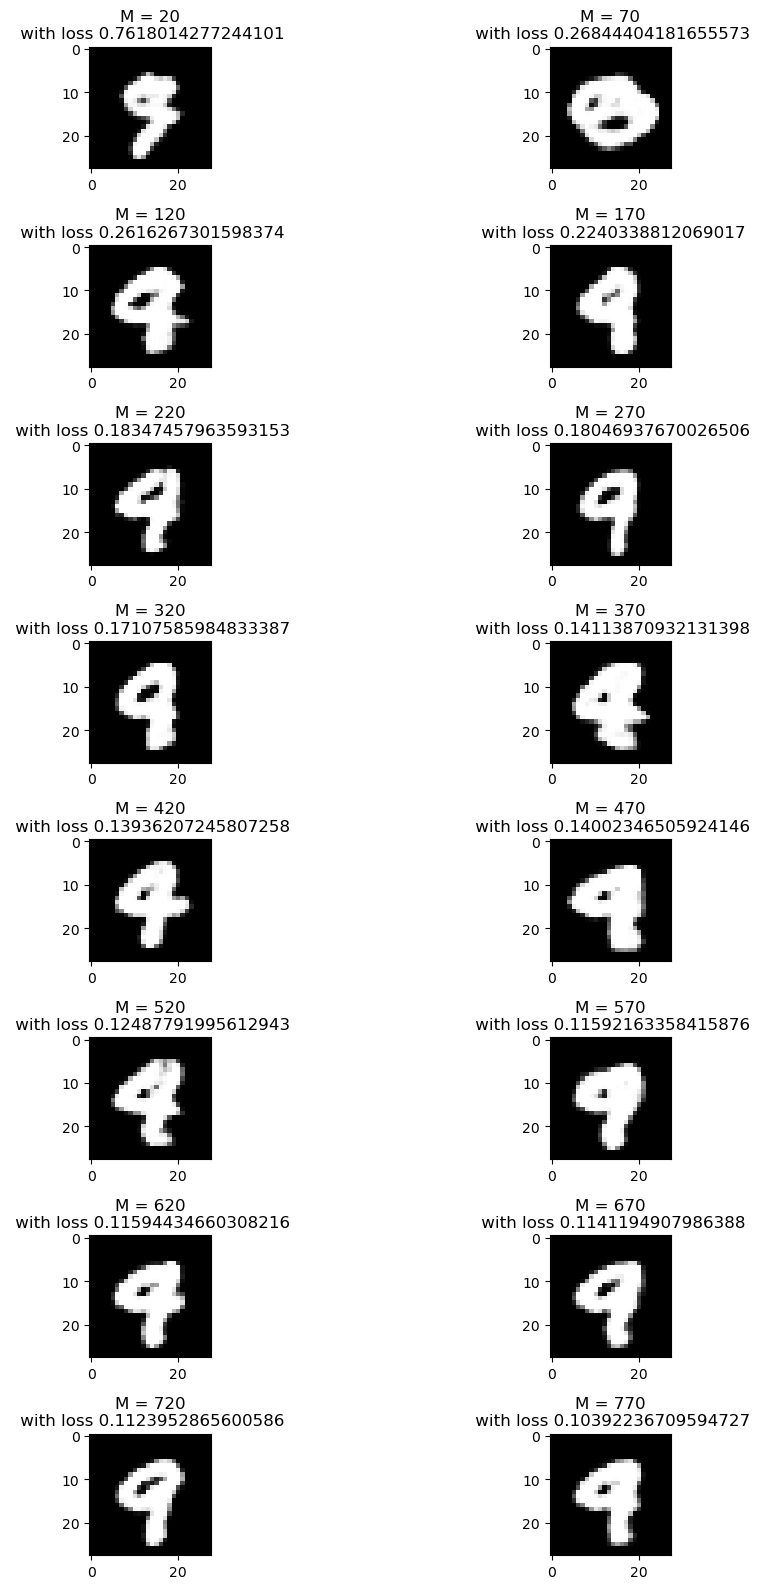

In [10]:
fig, axis = plt.subplots(8,2 , figsize = (12,16))
axis = axis.reshape((-1))
for i in range(len(reconstructions)):
    axis[i].imshow(reconstructions[i], cmap='gray')
    axis[i].set_title(f'M = {20 + i*50}\n with loss {losses[i]/784}')
fig.tight_layout()

Text(0.5, 1.0, 'Losses per pixel given M dimension of compressed sensing')

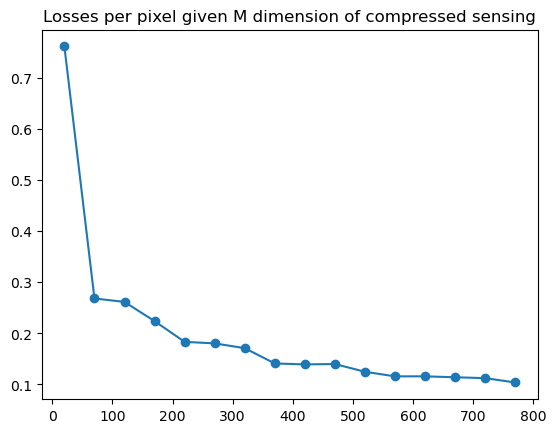

In [11]:
losses_norm = [loss / 784 for loss in losses]
plt.plot( range(20,784,50) , losses_norm, 'o-')
plt.title('Losses per pixel given M dimension of compressed sensing')